In [27]:
import random
import numpy as np
import torch

"""
    CITATION
    ----------
    ChatGPT was consulted for implementing a random seed in this code cell.
    My initial implementation was messy and hard to track given the number of
    code chunks in this notebook, so ChatGPT suggested the format in this cell.
"""
SEED = 2025

# Python
random.seed(SEED)

# NumPy
np.random.seed(SEED)

# PyTorch (CPU)
torch.manual_seed(SEED)

# PyTorch (GPU)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Ensure deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [28]:
import kagglehub

path = kagglehub.dataset_download(
    "hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images"
)

print(path)

Using Colab cache for faster access to the 'melanoma-skin-cancer-dataset-of-10000-images' dataset.
/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images


In [29]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    print(dirs)
    break

/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images
['melanoma_cancer_dataset']


In [30]:
base = os.path.join(path, "melanoma_cancer_dataset")

train_path = os.path.join(base, "train")
test_path  = os.path.join(base, "test")

In [31]:
from torch.utils.data import random_split, DataLoader
from torchvision import datasets, transforms

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# Two dataset objects pointing to the same folder, different transforms
full_train_dataset = datasets.ImageFolder(train_path, transform=train_transform)
full_val_dataset   = datasets.ImageFolder(train_path, transform=test_transform)

train_size = int(0.8 * len(full_train_dataset))
val_size   = len(full_train_dataset) - train_size

generator = torch.Generator().manual_seed(SEED)
train_dataset, _ = random_split(full_train_dataset, [train_size, val_size], generator=generator)
_, val_dataset   = random_split(full_val_dataset,   [train_size, val_size], generator=generator)

test_dataset = datasets.ImageFolder(test_path, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print("Classes:", full_train_dataset.classes)
print("Train Size:", len(train_dataset))
print("Validation Size:", len(val_dataset))
print("Test Size:", len(test_dataset))
print("Full Size:", len(full_train_dataset) + len(test_dataset))

Classes: ['benign', 'malignant']
Train Size: 7684
Validation Size: 1921
Test Size: 1000
Full Size: 10605


In [32]:
#Confirming the usage of cuda for GPU implementation
import torch
import torch.nn as nn
from torchvision import models

device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

cuda


In [33]:
#Checking for class imbalance
"""
    CITATION
    ----------
    ChatGPT was consulted for implementing Counter as a method for checking for
    class imbalance.
"""
from collections import Counter

malignant_count = Counter(full_train_dataset.targets)[1]
benign_count = Counter(full_train_dataset.targets)[0]

print("Malignant Class Count in Training Data:", malignant_count)
print("Benign Class Count in Training Data:", benign_count)


Malignant Class Count in Training Data: 4605
Benign Class Count in Training Data: 5000


In [34]:
#Implementing plot_training_curves() function used in previous homework for CS372
"""
    CITATION
    ----------
    This plot_training_curves() method is the same one used in Homework 4.
"""
from matplotlib import pyplot as plt

def plot_training_curves(train_losses, val_accuracies):
    """Plot training loss and validation accuracy curves.

    Parameters
    ----------
    train_losses : list of float
        Training loss values for each epoch. Should have one value per epoch.
    val_accuracies : list of float
        Validation accuracy values for each epoch. Should have same length as
        train_losses. Accuracy values should be between 0 and 1 (or 0 and 100
        if using percentages).

    Returns
    -------
    None
        Displays matplotlib figure with two subplots showing training curves.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(train_losses)
    ax1.set_title('Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True)

    ax2.plot(val_accuracies)
    ax2.set_title('Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# CNN

In [35]:
#Defining CNN
import torch
import torch.nn as nn
import torch.nn.functional as F
import time

class ResidualBlock(nn.Module):
    """Helper class that creates Residual Blocks for the CNN.

    Parameters
    ----------
    in_channels : int
        Number of input channels.
    out_channels : int
        Number of output channels.

    Returns
    -------
    Forwards a single Residual Block.
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        residual = x
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x += residual
        x = F.relu(x)
        return x

#224x224x3 to 55x55x96 to 27x27x96 to 13x13x256 to 13x13x384 to 13x13x256 to 6x6x256
#Flatten to 9216 to 4096 to 1000
class CNN(nn.Module):
    """Class for implementing the CNN.

    Uses
    ----------
    Several convolutional layers conv1, conv2, conv3, and conv4
    Batch Normalization
    Max Pooling
    Dropout Regularization with p = 0.5
    Fully-Connected Linear Layers fc1, fc2, and fc3
    ReLU Activation

    Returns
    -------
    Forwards CNN.
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 96, kernel_size = 11, padding = 2, stride = 4)
        self.bn1 = nn.BatchNorm2d(96)
        self.pool = nn.MaxPool2d(kernel_size = 3, stride = 2)

        self.conv2 = nn.Conv2d(96, 256, kernel_size = 5, padding = 2)
        self.bn2 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(kernel_size = 3, stride = 2)

        self.res1 = ResidualBlock(256, 256)

        self.conv3 = nn.Conv2d(256, 384, kernel_size = 3, padding = 1)
        self.bn3 = nn.BatchNorm2d(384)

        self.conv4 = nn.Conv2d(384, 256, kernel_size = 3, padding = 1)
        self.bn4 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(kernel_size = 3, stride = 2)
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 4096)
        self.fc2 = nn.Linear(4096, 1000)
        self.fc3 = nn.Linear(1000, 2)
        self.relu = nn.ReLU()


    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.pool(x)
        x = self.res1(x)
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.conv4(x)
        x = self.bn4(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.dropout(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

"""
    CITATION
    ----------
    ChatGPT was consulted for debugging the size of the fully-connected linear
    layers. When I would train the model, I would get an error that mat1 and
    mat2 shapes were different, so ChatGPT helped to explain this error and I
    was redirected to fixing the size of the fully-connected linear layers.
"""

'\n    CITATION\n    ----------\n    ChatGPT was consulted for debugging the size of the fully-connected linear\n    layers. When I would train the model, I would get an error that mat1 and\n    mat2 shapes were different, so ChatGPT helped to explain this error and I\n    was redirected to fixing the size of the fully-connected linear layers.\n'

Epoch 01/20 | Loss: 0.644 | Train acc: 78.3% | Val acc: 84.2% | Time: 32.9s
Epoch 02/20 | Loss: 0.401 | Train acc: 82.5% | Val acc: 85.6% | Time: 32.5s
Epoch 03/20 | Loss: 0.352 | Train acc: 84.4% | Val acc: 87.6% | Time: 32.5s
Epoch 04/20 | Loss: 0.348 | Train acc: 84.8% | Val acc: 87.3% | Time: 32.5s
Epoch 05/20 | Loss: 0.337 | Train acc: 85.8% | Val acc: 88.4% | Time: 32.7s
Epoch 06/20 | Loss: 0.312 | Train acc: 86.8% | Val acc: 88.6% | Time: 33.2s
Epoch 07/20 | Loss: 0.302 | Train acc: 87.4% | Val acc: 88.6% | Time: 33.3s
Epoch 08/20 | Loss: 0.299 | Train acc: 87.2% | Val acc: 89.7% | Time: 32.8s
Epoch 09/20 | Loss: 0.279 | Train acc: 88.7% | Val acc: 88.3% | Time: 32.3s
Epoch 10/20 | Loss: 0.285 | Train acc: 88.1% | Val acc: 90.1% | Time: 32.3s
Epoch 11/20 | Loss: 0.275 | Train acc: 88.8% | Val acc: 89.6% | Time: 32.6s
Epoch 12/20 | Loss: 0.264 | Train acc: 88.9% | Val acc: 89.8% | Time: 32.7s
Epoch 13/20 | Loss: 0.256 | Train acc: 89.4% | Val acc: 91.3% | Time: 32.9s
Epoch 14/20 

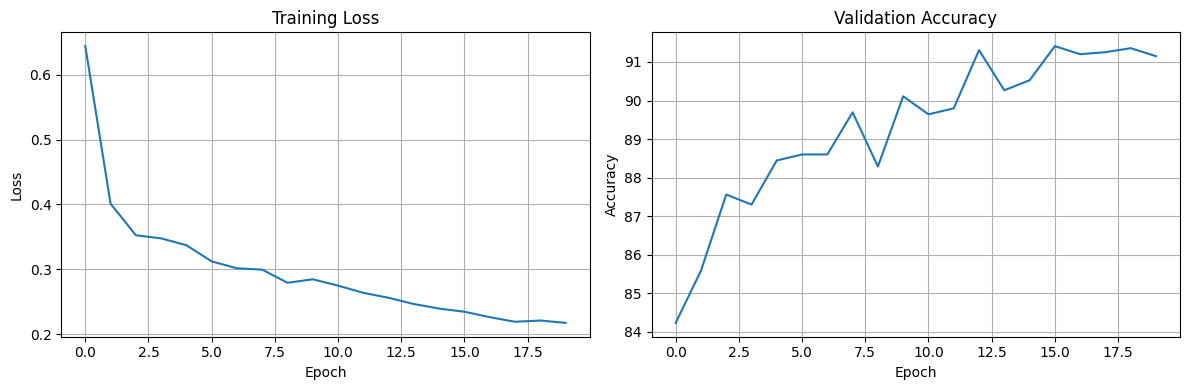

'\n    CITATION\n    ----------\n    ChatGPT was consulted for implementing the torch.save(model.state_dict())\n    syntax.\n'

In [36]:
#Training CNN
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
torch.manual_seed(SEED)

model = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = CosineAnnealingLR(optimizer, T_max=20)

patience = 2
max_num_epochs = 20
epochs_counter = 0

training_loss = []
validation_accuracy = []
start_time = time.time()

def train(model):
    epochs_counter = 0
    for epoch in range(max_num_epochs):
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        epoch_start_time = time.time()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)

            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        mean_loss = train_loss / len(train_loader)
        training_loss.append(mean_loss)

        scheduler.step()
        model.eval()
        val_correct, val_total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)

        val_acc = 100.* val_correct / val_total
        validation_accuracy.append(val_acc)


        print(f"Epoch {epoch+1:02d}/{max_num_epochs} | "
              f"Loss: {mean_loss:.3f} | "
              f"Train acc: {100.*correct/total:.1f}% | "
              f"Val acc: {val_acc:.1f}% | "
              f"Time: {time.time()-epoch_start_time:.1f}s")

        if len(validation_accuracy) > 1:
          if validation_accuracy[-1] <= validation_accuracy[-2]:
              epochs_counter += 1
              if epochs_counter == patience:
                  print("Early stopping triggered.")
                  break
          else:
              epochs_counter = 0

    print("Training complete.")

train(model)
plot_training_curves(training_loss, validation_accuracy)

torch.save(model.state_dict(), "cnn.pth")

"""
    CITATION
    ----------
    ChatGPT was consulted for implementing the torch.save(model.state_dict())
    syntax.
"""

# ResNet-18-Inspired Implementation

In [37]:
#Defining ResNet18
import torch
import torch.nn as nn
import torch.nn.functional as F
import time

class ResNet18(nn.Module):
    """Class for implementing the ResNet18.

    Uses
    ----------
    Backbone model resnet18
    Sequential stem with conv1, bn1, and relu
    Sequential layers layer1, layer2, layer3, and layer4
    Average Pooling
    Max Pooling
    Dropout Regularization with p = 0.5
    Linear Layers
    Linear Layers classifier
    ReLU Activation

    Returns
    -------
    Forwards ResNet18.
    """
    def __init__(self):
        super().__init__()

        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        self.stem = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
        )

        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 10000),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(10000, 2)
            )

    def forward(self, x):
      x = self.stem(x)
      x = self.layer1(x)
      x = self.layer2(x)
      x = self.layer3(x)
      x = self.layer4(x)
      x = self.gap(x)
      x = self.classifier(x)
      return x

"""
    CITATION
    ----------
    This ResNet-18-Inspired Implementation here used both the colab autofill
    (at the line-level) and some consultation of ChatGPT for the self.stem()
    class. In particular, the code of self.stem is AI-generated. Also, the
    website GeeksforGeeks was consulted for how to think through the
    forward() method. The website was a great resource for understanding a
    from-scratch implementation: https://www.geeksforgeeks.org/deep-learning/
    resnet18-from-scratch-using-pytorch/.
"""

'\n    CITATION\n    ----------\n    This ResNet-18-Inspired Implementation here used both the colab autofill\n    (at the line-level) and some consultation of ChatGPT for the self.stem()\n    class. In particular, the code of self.stem is AI-generated. Also, the\n    website GeeksforGeeks was consulted for how to think through the\n    forward() method. The website was a great resource for understanding a\n    from-scratch implementation: https://www.geeksforgeeks.org/deep-learning/\n    resnet18-from-scratch-using-pytorch/.\n'

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 264MB/s]


Epoch 01/20 | Loss: 0.503 | Train acc: 81.5% | Val acc: 67.7% | Time: 39.4s
Epoch 02/20 | Loss: 0.364 | Train acc: 85.3% | Val acc: 87.8% | Time: 39.8s
Epoch 03/20 | Loss: 0.336 | Train acc: 86.4% | Val acc: 89.3% | Time: 40.3s
Epoch 04/20 | Loss: 0.320 | Train acc: 87.6% | Val acc: 89.7% | Time: 40.2s
Epoch 05/20 | Loss: 0.316 | Train acc: 87.5% | Val acc: 89.2% | Time: 39.9s
Epoch 06/20 | Loss: 0.343 | Train acc: 87.3% | Val acc: 89.7% | Time: 39.4s
Epoch 07/20 | Loss: 0.387 | Train acc: 86.5% | Val acc: 88.5% | Time: 40.0s
Epoch 08/20 | Loss: 0.339 | Train acc: 86.6% | Val acc: 89.4% | Time: 40.4s
Epoch 09/20 | Loss: 0.293 | Train acc: 88.3% | Val acc: 90.1% | Time: 40.1s
Epoch 10/20 | Loss: 0.294 | Train acc: 88.7% | Val acc: 90.5% | Time: 39.8s
Epoch 11/20 | Loss: 0.288 | Train acc: 88.8% | Val acc: 91.0% | Time: 39.9s
Epoch 12/20 | Loss: 0.267 | Train acc: 89.5% | Val acc: 90.9% | Time: 39.9s
Epoch 13/20 | Loss: 0.250 | Train acc: 89.9% | Val acc: 91.6% | Time: 39.6s
Epoch 14/20 

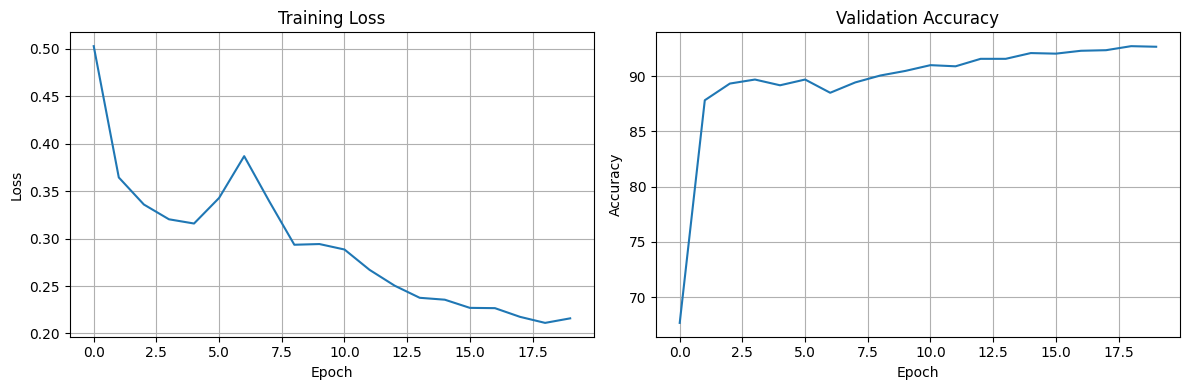

In [38]:
#Training ResNet18
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

torch.manual_seed(SEED)
model = ResNet18().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = CosineAnnealingLR(optimizer, T_max=20)

patience = 2
max_num_epochs = 20
epochs_counter = 0

training_loss = []
validation_accuracy = []
start_time = time.time()

def train(model):
    epochs_counter = 0
    for epoch in range(max_num_epochs):
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        epoch_start_time = time.time()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)

            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        mean_loss = train_loss / len(train_loader)
        training_loss.append(mean_loss)

        scheduler.step()
        model.eval()
        val_correct, val_total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)

        val_acc = 100.* val_correct / val_total
        validation_accuracy.append(val_acc)


        print(f"Epoch {epoch+1:02d}/{max_num_epochs} | "
              f"Loss: {mean_loss:.3f} | "
              f"Train acc: {100.*correct/total:.1f}% | "
              f"Val acc: {val_acc:.1f}% | "
              f"Time: {time.time()-epoch_start_time:.1f}s")

        if len(validation_accuracy) > 1:
          if validation_accuracy[-1] <= validation_accuracy[-2]:
              epochs_counter += 1
              if epochs_counter == patience:
                  print("Early stopping triggered.")
                  break
          else:
              epochs_counter = 0

    print("Training complete.")

train(model)
plot_training_curves(training_loss, validation_accuracy)

torch.save(model.state_dict(), "res18.pth")

# EfficientNet-B0-Inspired Implementation

In [39]:
#Defining EfficientNet-B0
import torch
import torch.nn as nn
import torch.nn.functional as F
import time

class Swish(nn.Module):
  """Class for implementing Swish


    Returns
    -------
    Swish Activation.
  """
  def forward(self, x):
    return x * torch.sigmoid(x)

class SEBlock(nn.Module):
  """Class for implementing Squeeve and Excitation Block

    Uses
    ----------
    in_channels : int
        Number of input channels.
    reduction_ratio : int
        Reduction ratio for squeeze and excitation.
    Average Pooling
    Linear Layers
    Sigmoid Activation

    Returns
    -------
    Applies Squeeze-and-Excitation.
  """
  def __init__(self, in_channels, reduction_ratio=4):
    super().__init__()
    self.avg_pool = nn.AdaptiveAvgPool2d(1)
    self.fc = nn.Sequential(
        nn.Linear(in_channels, in_channels // reduction_ratio),
        Swish(),
        nn.Linear(in_channels // reduction_ratio, in_channels),
        nn.Sigmoid()
    )

  def forward(self, x):
    b, c, _, _ = x.size()
    y = self.avg_pool(x).view(b, c)
    y = self.fc(y).view(b, c, 1, 1)
    return x * y


class MBConv(nn.Module):
  """Class for implementing Mobile Inverted Bottleneck Convolution

    Uses
    ----------
    in_channels : int
        Number of input channels.
    out_channels : int
        Number of output channels.
    kernel_size : int
        Kernel size for convolution.
    stride : int
        Stride for convolution.
    expand_ratio : int
        Expansion ratio for inverted bottleneck.
    Average Pooling
    Linear Layers
    Sigmoid Activation
    Batch Normalization
    Swish Activation

    Returns
    -------
    Implements Mobile-Inverted Bottleneck that downsample spatial dimensions
    and increase depth of feature maps.
  """
  def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, expand_ratio=1):
    super().__init__()
    self.use_residual = in_channels == out_channels and stride == 1
    hidden_dim = in_channels * expand_ratio
    layers = []
    if expand_ratio != 1:
      layers.append(nn.Conv2d(in_channels, hidden_dim, 1, 1, 0, bias=False))
      layers.append(nn.BatchNorm2d(hidden_dim))
      layers.append(Swish())

    layers.append(nn.Conv2d(hidden_dim, hidden_dim, kernel_size, stride, kernel_size//2, groups=hidden_dim, bias=False))
    layers.append(nn.BatchNorm2d(hidden_dim))
    layers.append(Swish())
    layers.append(SEBlock(hidden_dim))
    layers.append(nn.Conv2d(hidden_dim, out_channels, 1, 1, 0, bias=False))
    layers.append(nn.BatchNorm2d(out_channels))
    self.conv = nn.Sequential(*layers)

  def forward(self, x):
    out = self.conv(x)
    if self.use_residual:
      out = x + out
    return out


class My_EfficientNet(nn.Module):
  """Class for implementing EfficientNet-B0.

    Uses
    ----------
    Sequential Stem
    Sequential Layers
    Adaptive Average Pooling
    Flatten
    Dropout Regularization with p = 0.2
    Linear Layers
    Softmax Activation

    Returns
    -------
    Implements Mobile-Inverted Bottleneck that downsample spatial dimensions
    and increase depth of feature maps.
  """
  def __init__(self, num_classes=2):
    super().__init__()
    self.stem = nn.Sequential(
        nn.Conv2d(3, 32, 3, 2, 1, bias=False),
        nn.BatchNorm2d(32),
        Swish()
    )
    self.blocks = nn.Sequential(
        MBConv(32, 16, 3, 1, 1),
        MBConv(16, 24, 3, 2, 6),
        MBConv(24, 24, 3, 1, 6),
        MBConv(24, 40, 5, 2, 6),
        MBConv(40, 40, 5, 1, 6),
        MBConv(40, 80, 3, 2, 6),
        MBConv(80, 80, 3, 1, 6),
        MBConv(80, 80, 3, 1, 6),
        MBConv(80, 112, 5, 1, 6),
        MBConv(112, 112, 5, 1, 6),
        MBConv(112, 192, 5, 1, 6),
        MBConv(192, 192, 5, 1, 6),
        MBConv(192, 192, 5, 1, 6),
        MBConv(192, 192, 5, 1, 6),
        MBConv(192, 320, 3, 1, 6),
    )
    self.chead = nn.Sequential(
        nn.Conv2d(320, 1280, 1, 1, 0, bias=False),
        nn.BatchNorm2d(1280),
        Swish()
    )

    self.head = nn.Sequential(
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Dropout(0.2),
        nn.Linear(1280, num_classes)
    )

    self.softmax = nn.Softmax(dim=1)

  def forward(self, x):
    x = self.stem(x)
    x = self.blocks(x)
    x = self.chead(x)
    x = self.head(x)
    x = self.softmax(x)
    return x

"""
    CITATION
    ----------
    The EfficientNet-B0 Implementation here used both the colab autofill
    (at the line-level) and some consultation of ChatGPT for the self.chead()
    and MBConv() class. In particular, the code of self.stem is AI-generated,
    and the implementation of SEBlock() is AI-generated. The SEBlock() was by
    far one of the most challenging things to implement in this project, and
    ChatGPT was helpful for debugging and code-generation.
"""

'\n    CITATION\n    ----------\n    The EfficientNet-B0 Implementation here used both the colab autofill\n    (at the line-level) and some consultation of ChatGPT for the self.chead()\n    and MBConv() class. In particular, the code of self.stem is AI-generated,\n    and the implementation of SEBlock() is AI-generated. The SEBlock() was by\n    far one of the most challenging things to implement in this project, and\n    ChatGPT was helpful for debugging and code-generation.\n'

Epoch 01/20 | Loss: 0.520 | Train acc: 78.3% | Val acc: 84.9% | Time: 37.8s
Epoch 02/20 | Loss: 0.465 | Train acc: 84.1% | Val acc: 88.5% | Time: 37.0s
Epoch 03/20 | Loss: 0.444 | Train acc: 86.2% | Val acc: 89.6% | Time: 37.6s
Epoch 04/20 | Loss: 0.438 | Train acc: 86.9% | Val acc: 89.3% | Time: 37.3s
Epoch 05/20 | Loss: 0.435 | Train acc: 87.2% | Val acc: 90.6% | Time: 37.5s
Epoch 06/20 | Loss: 0.425 | Train acc: 88.3% | Val acc: 90.7% | Time: 37.2s
Epoch 07/20 | Loss: 0.424 | Train acc: 88.3% | Val acc: 90.7% | Time: 37.4s
Epoch 08/20 | Loss: 0.418 | Train acc: 89.1% | Val acc: 90.2% | Time: 37.6s
Early stopping triggered.
Training complete.


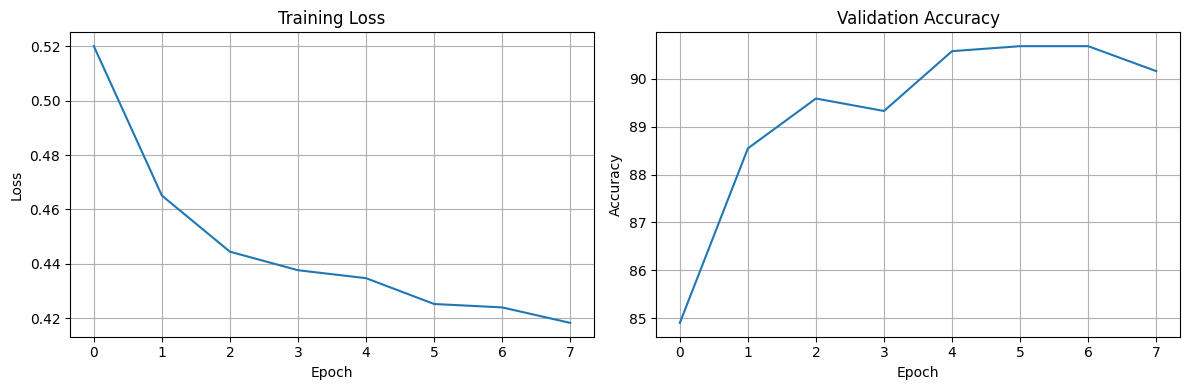

In [40]:
#Training EfficientNet-B0
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

torch.manual_seed(SEED)
model = My_EfficientNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = CosineAnnealingLR(optimizer, T_max=20)

patience = 2
max_num_epochs = 20
epochs_counter = 0

training_loss = []
validation_accuracy = []
start_time = time.time()

def train(model):
    epochs_counter = 0
    for epoch in range(max_num_epochs):
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        epoch_start_time = time.time()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)

            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        mean_loss = train_loss / len(train_loader)
        training_loss.append(mean_loss)

        scheduler.step()
        model.eval()
        val_correct, val_total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)

        val_acc = 100.* val_correct / val_total
        validation_accuracy.append(val_acc)


        print(f"Epoch {epoch+1:02d}/{max_num_epochs} | "
              f"Loss: {mean_loss:.3f} | "
              f"Train acc: {100.*correct/total:.1f}% | "
              f"Val acc: {val_acc:.1f}% | "
              f"Time: {time.time()-epoch_start_time:.1f}s")

        if len(validation_accuracy) > 1:
          if validation_accuracy[-1] <= validation_accuracy[-2]:
              epochs_counter += 1
              if epochs_counter == patience:
                  print("Early stopping triggered.")
                  break
          else:
              epochs_counter = 0

    print("Training complete.")

train(model)
plot_training_curves(training_loss, validation_accuracy)

torch.save(model.state_dict(), "efficient-b0.pth")

# ViT-16

In [41]:
#Defining ViT
class VisionTransformer(nn.Module):
    """Class for implementing pre-trained ViT-b16.

    Uses
    ----------
    Backbone model vit_b_16
    Replaces head layers for binary classes (benign and malignant)

    Returns
    -------
    ViT Model for binary classes.
    """
    def __init__(self):
        super().__init__()
        self.vit = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
        in_features = self.vit.heads.head.in_features
        self.vit.heads = nn.Linear(in_features, 2)


    def forward(self, x):
        return self.vit(x)


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 200MB/s]


Epoch 01/20 | Loss: 0.563 | Train acc: 73.1% | Val acc: 77.5% | Time: 52.5s
Epoch 02/20 | Loss: 0.420 | Train acc: 80.3% | Val acc: 82.5% | Time: 51.9s
Epoch 03/20 | Loss: 0.396 | Train acc: 82.3% | Val acc: 81.3% | Time: 52.6s
Epoch 04/20 | Loss: 0.391 | Train acc: 83.2% | Val acc: 83.6% | Time: 53.2s
Epoch 05/20 | Loss: 0.374 | Train acc: 83.9% | Val acc: 83.1% | Time: 52.3s
Epoch 06/20 | Loss: 0.361 | Train acc: 83.9% | Val acc: 84.2% | Time: 52.5s
Epoch 07/20 | Loss: 0.364 | Train acc: 83.9% | Val acc: 83.9% | Time: 51.9s
Epoch 08/20 | Loss: 0.351 | Train acc: 84.7% | Val acc: 85.2% | Time: 52.6s
Epoch 09/20 | Loss: 0.342 | Train acc: 85.1% | Val acc: 85.6% | Time: 53.0s
Epoch 10/20 | Loss: 0.335 | Train acc: 84.9% | Val acc: 84.0% | Time: 51.8s
Epoch 11/20 | Loss: 0.333 | Train acc: 85.7% | Val acc: 85.3% | Time: 53.1s
Epoch 12/20 | Loss: 0.322 | Train acc: 85.9% | Val acc: 86.4% | Time: 52.7s
Epoch 13/20 | Loss: 0.309 | Train acc: 86.3% | Val acc: 85.7% | Time: 52.9s
Epoch 14/20 

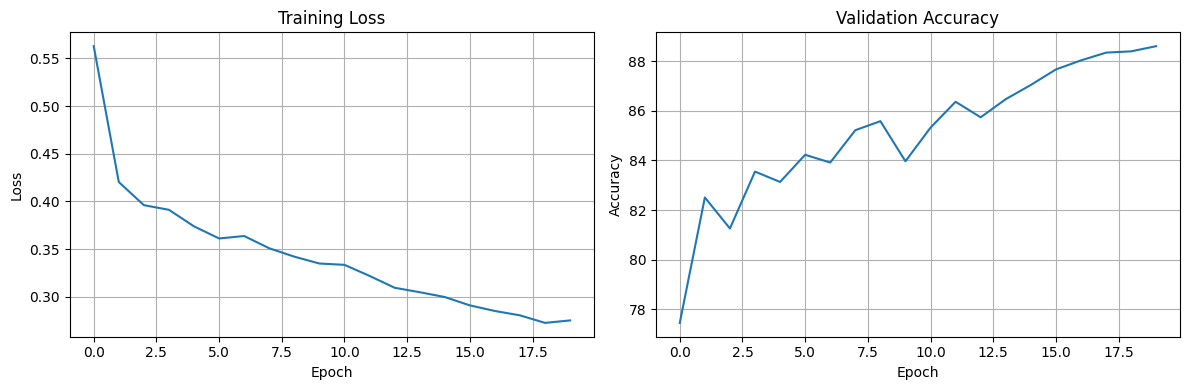

In [42]:
#Training ViT
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

torch.manual_seed(SEED)
model = VisionTransformer().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = CosineAnnealingLR(optimizer, T_max=20)

patience = 2
max_num_epochs = 20
epochs_counter = 0

training_loss = []
validation_accuracy = []
start_time = time.time()

def train(model):
    epochs_counter = 0
    for epoch in range(max_num_epochs):
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        epoch_start_time = time.time()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)

            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        mean_loss = train_loss / len(train_loader)
        training_loss.append(mean_loss)

        scheduler.step()
        model.eval()
        val_correct, val_total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)

        val_acc = 100.* val_correct / val_total
        validation_accuracy.append(val_acc)


        print(f"Epoch {epoch+1:02d}/{max_num_epochs} | "
              f"Loss: {mean_loss:.3f} | "
              f"Train acc: {100.*correct/total:.1f}% | "
              f"Val acc: {val_acc:.1f}% | "
              f"Time: {time.time()-epoch_start_time:.1f}s")

        if len(validation_accuracy) > 1:
          if validation_accuracy[-1] <= validation_accuracy[-2]:
              epochs_counter += 1
              if epochs_counter == patience:
                  print("Early stopping triggered.")
                  break
          else:
              epochs_counter = 0

    print("Training complete.")

train(model)
plot_training_curves(training_loss, validation_accuracy)

torch.save(model.state_dict(), "vit.pth")

# Trying AdamW as Optimizer for EfficientNet-B0

Epoch 01/20 | Loss: 0.518 | Train acc: 78.6% | Val acc: 87.2% | Time: 37.5s
Epoch 02/20 | Loss: 0.458 | Train acc: 84.9% | Val acc: 88.2% | Time: 37.8s
Epoch 03/20 | Loss: 0.444 | Train acc: 86.3% | Val acc: 89.6% | Time: 37.5s
Epoch 04/20 | Loss: 0.436 | Train acc: 87.3% | Val acc: 89.8% | Time: 37.6s
Epoch 05/20 | Loss: 0.434 | Train acc: 87.4% | Val acc: 90.5% | Time: 36.9s
Epoch 06/20 | Loss: 0.425 | Train acc: 88.4% | Val acc: 90.2% | Time: 37.4s
Epoch 07/20 | Loss: 0.430 | Train acc: 87.6% | Val acc: 90.2% | Time: 37.6s
Epoch 08/20 | Loss: 0.417 | Train acc: 89.2% | Val acc: 90.8% | Time: 37.7s
Epoch 09/20 | Loss: 0.420 | Train acc: 88.8% | Val acc: 90.6% | Time: 37.7s
Epoch 10/20 | Loss: 0.411 | Train acc: 89.7% | Val acc: 91.5% | Time: 38.3s
Epoch 11/20 | Loss: 0.409 | Train acc: 90.1% | Val acc: 91.8% | Time: 37.2s
Epoch 12/20 | Loss: 0.407 | Train acc: 90.3% | Val acc: 91.5% | Time: 37.7s
Epoch 13/20 | Loss: 0.406 | Train acc: 90.5% | Val acc: 91.7% | Time: 37.4s
Epoch 14/20 

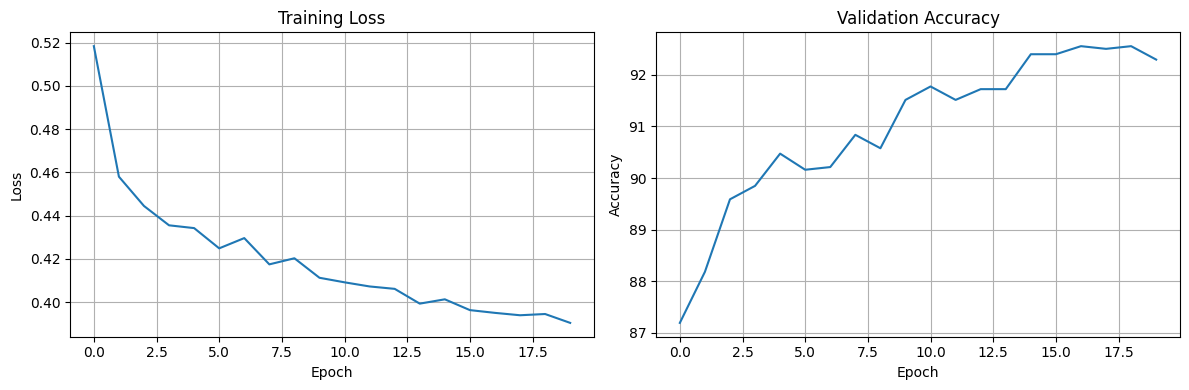

In [43]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

torch.manual_seed(SEED)
model = My_EfficientNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-2)
scheduler = CosineAnnealingLR(optimizer, T_max=20)

patience = 2
max_num_epochs = 20
epochs_counter = 0

training_loss = []
validation_accuracy = []
start_time = time.time()

def train(model):
    epochs_counter = 0
    for epoch in range(max_num_epochs):
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        epoch_start_time = time.time()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)

            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        mean_loss = train_loss / len(train_loader)
        training_loss.append(mean_loss)

        scheduler.step()
        model.eval()
        val_correct, val_total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)

        val_acc = 100.* val_correct / val_total
        validation_accuracy.append(val_acc)


        print(f"Epoch {epoch+1:02d}/{max_num_epochs} | "
              f"Loss: {mean_loss:.3f} | "
              f"Train acc: {100.*correct/total:.1f}% | "
              f"Val acc: {val_acc:.1f}% | "
              f"Time: {time.time()-epoch_start_time:.1f}s")

        if len(validation_accuracy) > 1:
          if validation_accuracy[-1] <= validation_accuracy[-2]:
              epochs_counter += 1
              if epochs_counter == patience:
                  print("Early stopping triggered.")
                  break
          else:
              epochs_counter = 0

    print("Training complete.")

train(model)
plot_training_curves(training_loss, validation_accuracy)

# Trying SGD as Optimizer for EfficientNet-B0

Epoch 01/20 | Loss: 0.633 | Train acc: 64.9% | Val acc: 78.6% | Time: 37.7s
Epoch 02/20 | Loss: 0.514 | Train acc: 79.2% | Val acc: 84.3% | Time: 37.4s
Epoch 03/20 | Loss: 0.475 | Train acc: 83.4% | Val acc: 87.8% | Time: 37.8s
Epoch 04/20 | Loss: 0.457 | Train acc: 85.2% | Val acc: 89.6% | Time: 37.1s
Epoch 05/20 | Loss: 0.446 | Train acc: 86.4% | Val acc: 88.9% | Time: 37.3s
Epoch 06/20 | Loss: 0.443 | Train acc: 86.5% | Val acc: 89.1% | Time: 37.3s
Epoch 07/20 | Loss: 0.434 | Train acc: 87.5% | Val acc: 90.3% | Time: 37.1s
Epoch 08/20 | Loss: 0.430 | Train acc: 87.9% | Val acc: 90.9% | Time: 37.5s
Epoch 09/20 | Loss: 0.429 | Train acc: 88.1% | Val acc: 90.0% | Time: 36.9s
Epoch 10/20 | Loss: 0.429 | Train acc: 87.8% | Val acc: 90.5% | Time: 37.6s
Epoch 11/20 | Loss: 0.424 | Train acc: 88.6% | Val acc: 91.3% | Time: 37.6s
Epoch 12/20 | Loss: 0.426 | Train acc: 88.1% | Val acc: 90.4% | Time: 37.8s
Epoch 13/20 | Loss: 0.419 | Train acc: 89.0% | Val acc: 91.4% | Time: 37.1s
Epoch 14/20 

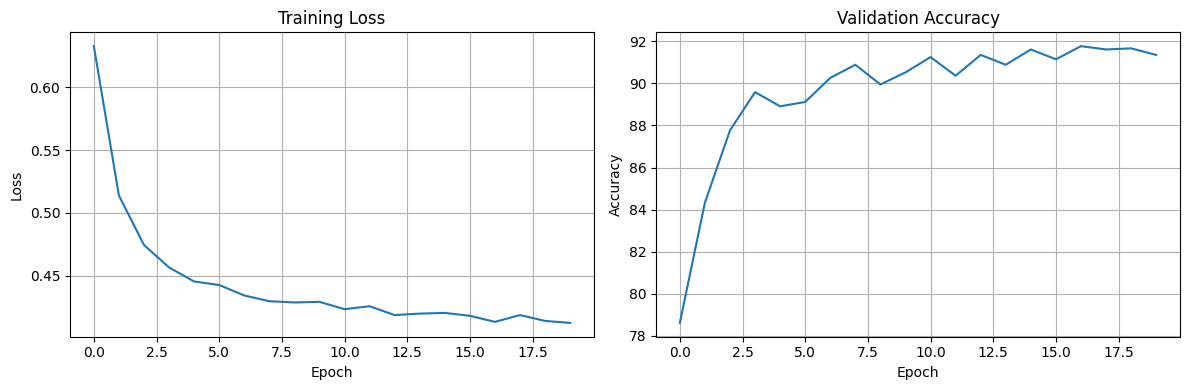

In [44]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

torch.manual_seed(SEED)
model = My_EfficientNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
scheduler = CosineAnnealingLR(optimizer, T_max=20)

patience = 2
max_num_epochs = 20
epochs_counter = 0

training_loss = []
validation_accuracy = []
start_time = time.time()

def train(model):
    epochs_counter = 0
    for epoch in range(max_num_epochs):
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        epoch_start_time = time.time()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)

            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        mean_loss = train_loss / len(train_loader)
        training_loss.append(mean_loss)

        scheduler.step()
        model.eval()
        val_correct, val_total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)

        val_acc = 100.* val_correct / val_total
        validation_accuracy.append(val_acc)


        print(f"Epoch {epoch+1:02d}/{max_num_epochs} | "
              f"Loss: {mean_loss:.3f} | "
              f"Train acc: {100.*correct/total:.1f}% | "
              f"Val acc: {val_acc:.1f}% | "
              f"Time: {time.time()-epoch_start_time:.1f}s")

        if len(validation_accuracy) > 1:
          if validation_accuracy[-1] <= validation_accuracy[-2]:
              epochs_counter += 1
              if epochs_counter == patience:
                  print("Early stopping triggered.")
                  break
          else:
              epochs_counter = 0

    print("Training complete.")

train(model)
plot_training_curves(training_loss, validation_accuracy)

# Sensitivity, Specificity Analysis on CNN, ResNet-18, EfficientNet-B0, and ViT

In [45]:
cnn = CNN().to(device)
cnn.load_state_dict(torch.load("cnn.pth", map_location=device))

res18 = ResNet18().to(device)
res18.load_state_dict(torch.load("res18.pth", map_location=device))

efficientnet = My_EfficientNet().to(device)
efficientnet.load_state_dict(torch.load("efficient-b0.pth", map_location=device))

vit = VisionTransformer().to(device)
vit.load_state_dict(torch.load("vit.pth", map_location=device))

"""
    CITATION
    ----------
    The idea of saving the above models and subsequently loading them from the
    state_dict() comes from debugging using AI. ChatGPT was helpful.
    This code chunk is ChatGPT-generated for loading the models.
"""

'\n    CITATION\n    ----------\n    The idea of saving the above models and subsequently loading them from the\n    state_dict() comes from debugging using AI. ChatGPT was helpful.\n    This code chunk is ChatGPT-generated for loading the models.\n'

CNN → Test Accuracy: 90.00% | Correct: 900 | Incorrect: 100


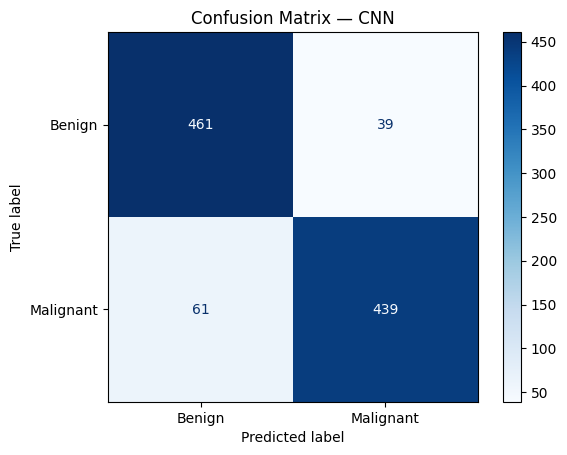

CNN: 61 false negatives found


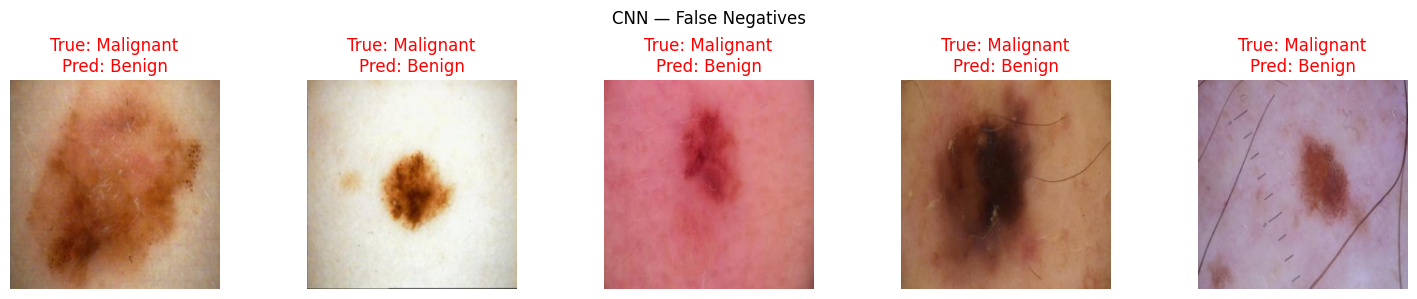

CNN: 39 false positives found


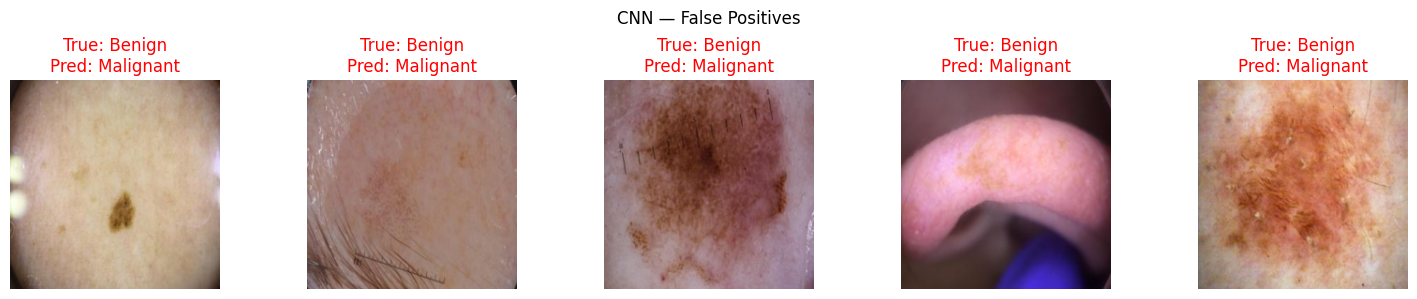

ResNet18 → Test Accuracy: 91.50% | Correct: 915 | Incorrect: 85


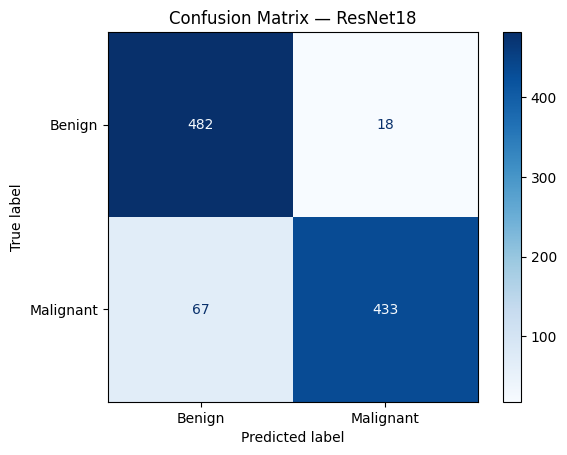

ResNet18: 67 false negatives found


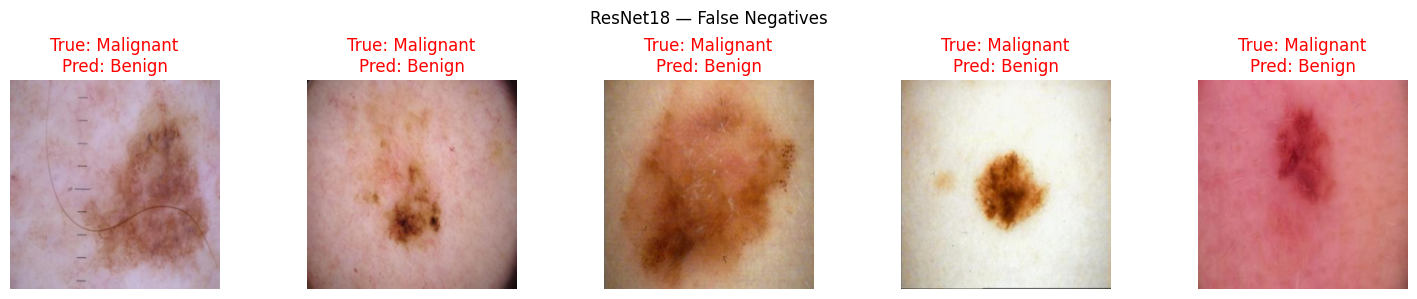

ResNet18: 18 false positives found


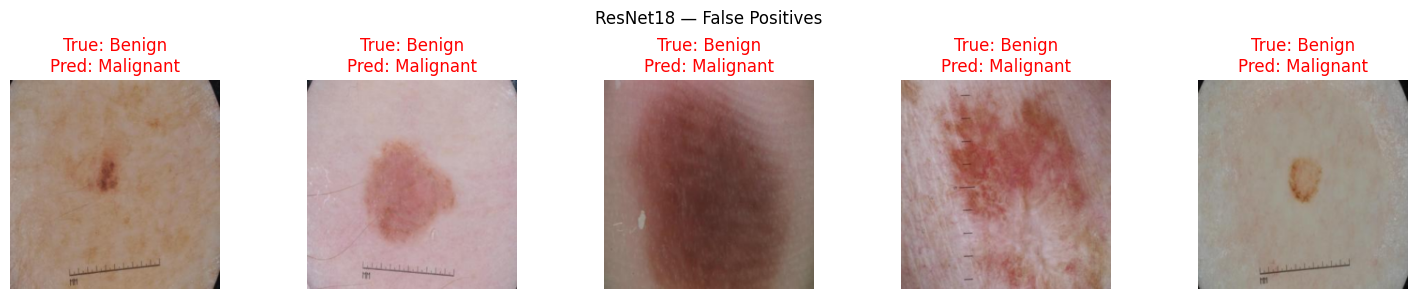

EfficientNet → Test Accuracy: 91.20% | Correct: 912 | Incorrect: 88


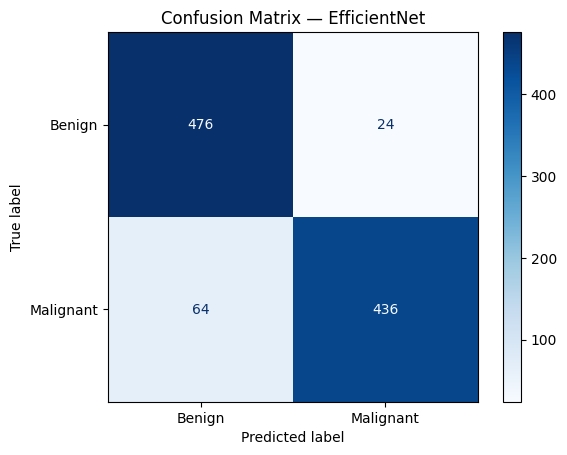

EfficientNet: 64 false negatives found


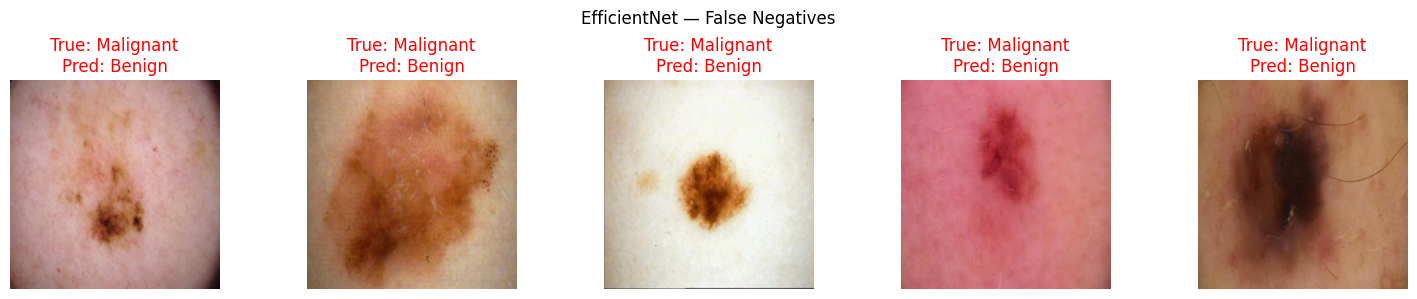

EfficientNet: 24 false positives found


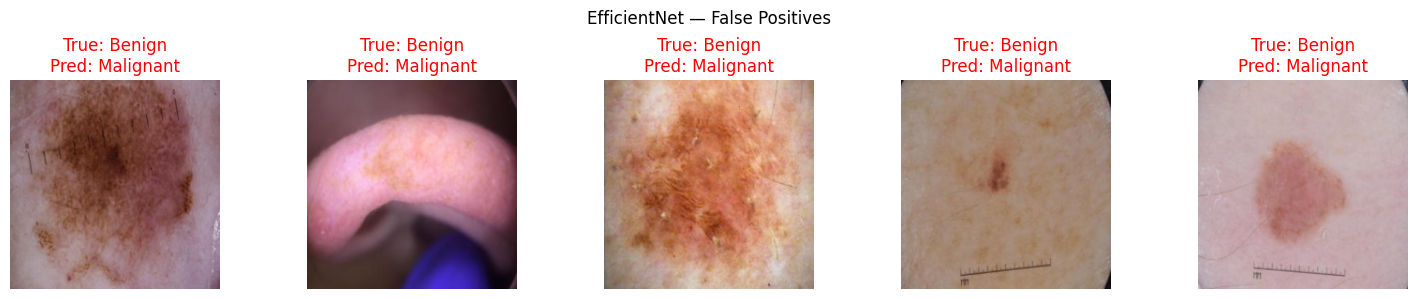

ViT → Test Accuracy: 87.20% | Correct: 872 | Incorrect: 128


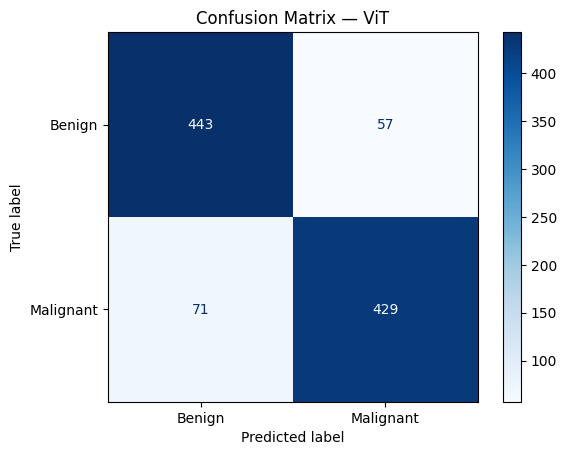

ViT: 71 false negatives found


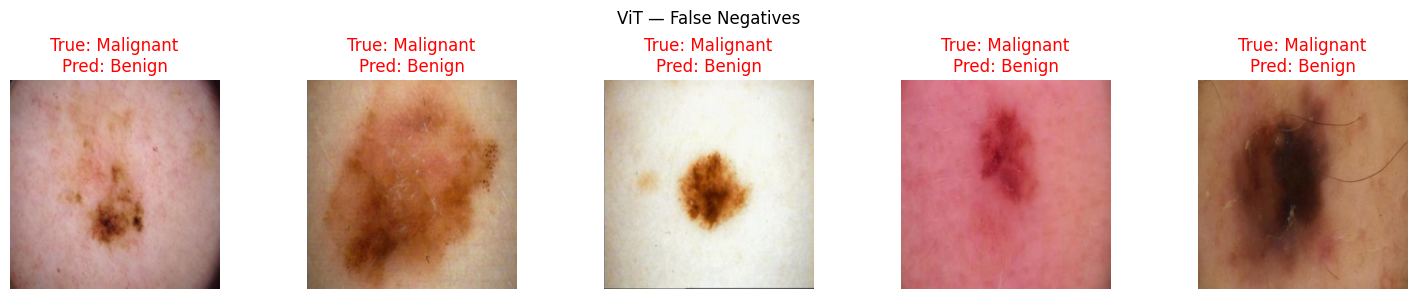

ViT: 57 false positives found


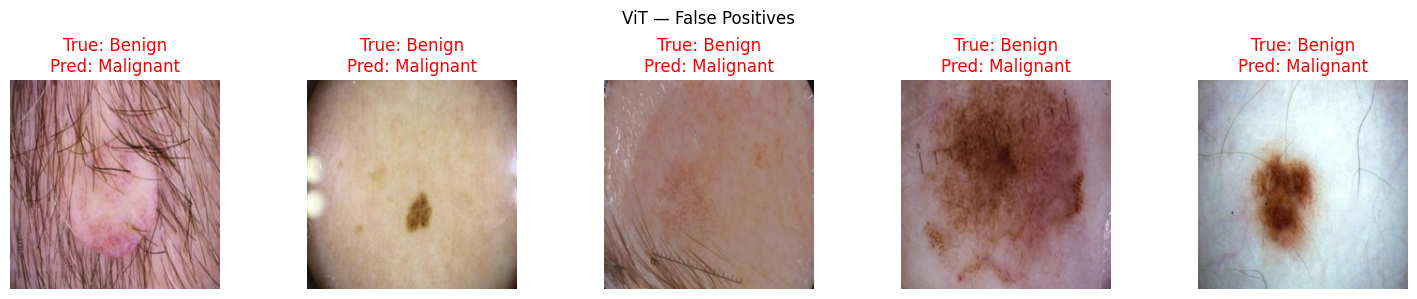

'\n    CITATION\n    ----------\n    The implementation of the for-loop directly above this comment is\n    Claude-AI-generated. My initial implementation was disorganized and had\n    unecessary repeated chunks of code. The methods above were\n    ClaudeAI-generated, and I subsequently revised and edited. Claude was\n    especially helpful for formatting the text and displaying the images in a\n    way that was easy to understand and would be visually appealing.\n'

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_model(model, test_loader, device):
    """Helper function for running models on test data.

    Uses
    ----------
    test_loader
    Tracks correct and incorrect predictions

    Returns
    -------
    accuracy, correct_samples, incorrect_samples, all_images,
    all_preds, all_labels
    """
    model.eval()
    correct_samples = []
    incorrect_samples = []
    all_images = []
    all_preds = []
    all_labels = []

    total = 0
    correct = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_images.extend(images.cpu())
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            for i in range(len(predicted)):
                if predicted[i] != labels[i]:
                    incorrect_samples.append((images[i].cpu(), predicted[i].cpu(), labels[i].cpu()))
                else:
                    correct_samples.append((images[i].cpu(), predicted[i].cpu(), labels[i].cpu()))

    accuracy = 100 * correct / total
    return accuracy, correct_samples, incorrect_samples, all_images, all_preds, all_labels


def plot_confusion_matrix(all_preds, all_labels, model_name):
    """Plots confusion matrix

    Uses
    ----------
    all_preds, all_labels, model

    Returns
    -------
    Plot of confusion matrix with appropriate labels.
    """
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Benign", "Malignant"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {model_name}")
    plt.show()


def show_fn_examples(all_images, all_preds, all_labels, model_name, n=5):
    """Displays 5 examples of the false negative class

    Uses
    ----------
    all_images, all_preds, all_labels, model_name

    Returns
    -------
    Examples of test images that were incorrectly classified as benign
    """
    fn_images = [
        img for img, pred, label in zip(all_images, all_preds, all_labels)
        if label == 1 and pred == 0
    ]
    print(f"{model_name}: {len(fn_images)} false negatives found")

    fig, axes = plt.subplots(1, min(n, len(fn_images)), figsize=(15, 3))
    for ax, img in zip(axes, fn_images[:n]):
        img = img * 0.5 + 0.5
        ax.imshow(img.permute(1, 2, 0).clamp(0, 1))
        ax.set_title("True: Malignant\nPred: Benign", color="red")
        ax.axis("off")
    plt.suptitle(f"{model_name} — False Negatives")
    plt.tight_layout()
    plt.show()

def show_fp_examples(all_images, all_preds, all_labels, model_name, n=5):
    """Displays 5 examples of the false positive class

    Uses
    ----------
    all_images, all_preds, all_labels, model_name

    Returns
    -------
    Examples of test images that were incorrectly classified as malignant.
    """
    fn_images = [
        img for img, pred, label in zip(all_images, all_preds, all_labels)
        if label == 0 and pred == 1
    ]
    print(f"{model_name}: {len(fn_images)} false positives found")

    fig, axes = plt.subplots(1, min(n, len(fn_images)), figsize=(15, 3))
    for ax, img in zip(axes, fn_images[:n]):
        img = img * 0.5 + 0.5
        ax.imshow(img.permute(1, 2, 0).clamp(0, 1))
        ax.set_title("True: Benign\nPred: Malignant", color="red")
        ax.axis("off")
    plt.suptitle(f"{model_name} — False Positives")
    plt.tight_layout()
    plt.show()



for name, m in [("CNN", cnn), ("ResNet18", res18), ("EfficientNet", efficientnet), ("ViT", vit)]:
    acc, correct_samples, incorrect_samples, all_images, all_preds, all_labels = evaluate_model(m, test_loader, device)
    print(f"{name} → Test Accuracy: {acc:.2f}% | Correct: {len(correct_samples)} | Incorrect: {len(incorrect_samples)}")
    plot_confusion_matrix(all_preds, all_labels, name)
    show_fn_examples(all_images, all_preds, all_labels, name)
    show_fp_examples(all_images, all_preds, all_labels, name)

"""
    CITATION
    ----------
    The implementation of the for-loop directly above this comment is
    Claude-AI-generated. My initial implementation was disorganized and had
    unecessary repeated chunks of code. The methods above were
    ClaudeAI-generated, and I subsequently revised and edited. Claude was
    especially helpful for formatting the text and displaying the images in a
    way that was easy to understand and would be visually appealing.
"""